# Teste de Visualização da Imagem `lixo-dt2-00111`

Este notebook carrega a imagem original de `garbage-8uzha` mapeada para o arquivo `lixo-dt2-00111.jpg` e plota a imagem com as anotações originais para verificar se há alguma distorção no cálculo dos retângulos (bounding boxes).

In [1]:
# Adiciona o diretório raiz ao path para importação do módulo src
import sys
import os
sys.path.append(os.path.abspath('..'))

In [2]:
import cv2
import matplotlib.pyplot as plt

# Caminhos originais para lixo-dt2-00111
img_path = '../data/raw/garbage-8uzha/train/images/9_dsp_su_11-10_09-33-13_for_DF5_jpg.rf.3116759f0a2c7fd084664c1200ef9592.jpg'
label_path = '../data/raw/garbage-8uzha/train/labels/9_dsp_su_11-10_09-33-13_for_DF5_jpg.rf.3116759f0a2c7fd084664c1200ef9592.txt'

print("Existe imagem:", os.path.exists(img_path))
print("Existe label:", os.path.exists(label_path))

Existe imagem: True
Existe label: True


### Desenhar Anotações da Imagem

Vamos ler a imagem e o arquivo txt, desenhar as caixas corretas na imagem e exibi-la.

Coordenadas originais no arquivo de texto:
Classe: 0 | Centro: (0.453125, 0.24921875) | Tam: (0.06015625, 0.0953125)
Classe: 0 | Centro: (0.4671875, 0.2890625) | Tam: (0.06171875, 0.08203125)


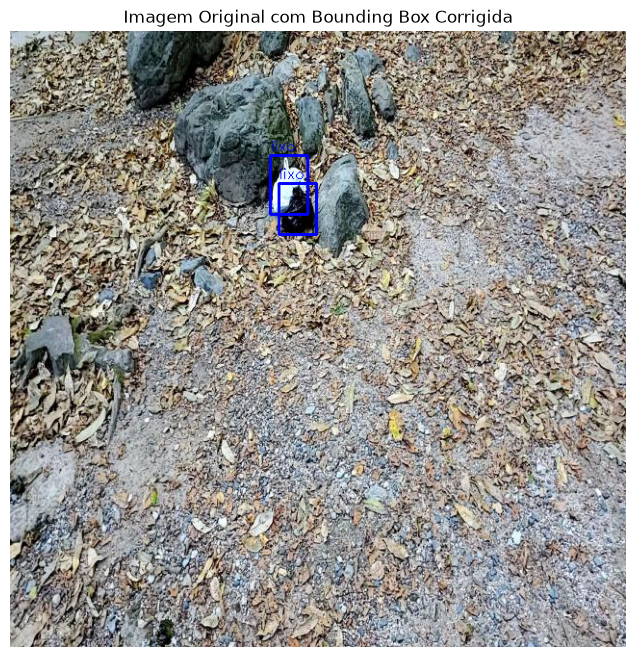

In [4]:
img = cv2.imread(img_path)
h, w, _ = img.shape

with open(label_path, 'r') as f:
    lines = f.readlines()

print("Coordenadas originais no arquivo de texto:")
for line in lines:
    parts = line.strip().split()
    if len(parts) >= 5:
        class_id = int(parts[0])
        x_c, y_c, box_w, box_h = map(float, parts[1:5])
        print(f"Classe: {class_id} | Centro: ({x_c}, {y_c}) | Tam: ({box_w}, {box_h})")
        
        # Fórmula corrigida:
        x1 = int((x_c - box_w / 2) * w)
        y1 = int((y_c - box_h / 2) * h)
        x2 = int((x_c + box_w / 2) * w)
        y2 = int((y_c + box_h / 2) * h) # <-- usando y_c
        
        # Desenha a caixa em azul (BGR)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(img, f"lixo", (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title("Imagem Original com Bounding Box Corrigida")
plt.axis('off')
plt.show()